# 🛒 Customer Segmentation Analysis
### E-Commerce Customer Intelligence using K-Means Clustering
---
**Author:** Siddharth Khedekar  
**Dataset:** Synthetic Indian E-Commerce Dataset (1,000 customers | 13,740 transactions)  
**Stack:** Python · Scikit-learn · Pandas · Matplotlib · Seaborn  
**Goal:** Identify distinct customer groups using RFM + behavioural features to enable targeted marketing strategies.

---
## 📋 Table of Contents
1. [Project Overview](#overview)
2. [Exploratory Data Analysis](#eda)
3. [Feature Engineering](#features)
4. [Preprocessing & Optimal K Selection](#preprocessing)
5. [K-Means Clustering](#kmeans)
6. [Cluster Profiling & Business Insights](#profiling)
7. [Final Dashboard](#dashboard)
8. [Recommendations](#recommendations)


## 0. Environment Setup

In [ ]:
# ─────────────────────────────────────────────────────────────
# Import all libraries needed across the notebook.
#
# pandas  → tabular data manipulation (DataFrames)
# numpy   → numerical computations
# matplotlib / seaborn → plotting & visualisation
# sklearn → machine learning (KMeans, PCA, scalers, metrics)
# joblib  → save/load fitted model objects (.pkl files)
# pathlib → cross-platform file paths (works on Windows & Linux)
# warnings → suppress noisy deprecation warnings during demo
# ─────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')          # Non-interactive backend — saves files instead of opening windows
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')  # Consistent plot styling throughout

# ── Project directory structure ──────────────────────────────
# BASE_DIR points to the project root.
# All other paths are derived from it so the notebook is portable.
BASE_DIR   = Path('/home/claude/customer_segmentation')
DATA_DIR   = BASE_DIR / 'data'       # Raw & processed CSVs
OUTPUT_DIR = BASE_DIR / 'outputs'    # Models, scalers, summary CSVs
PLOT_DIR   = OUTPUT_DIR / 'plots'    # All saved PNG visualisations

print("✅ Libraries loaded")
print(f"   Base directory : {BASE_DIR}")
print(f"   Data directory : {DATA_DIR}")
print(f"   Output directory: {OUTPUT_DIR}")


---
## 1. Project Overview <a id='overview'></a>

### Business Problem
A mid-size Indian e-commerce company wants to move beyond one-size-fits-all marketing.  
The goal is to **group customers into meaningful segments** so each segment gets tailored communication, offers, and retention strategies.

### Approach — RFM + Behavioural Clustering
| Feature Group | Features Used |
|---|---|
| **RFM** | Recency (days since last order), Frequency (order count), Monetary (total & avg spend) |
| **Behavioural** | Website visits, spend per visit, purchase rate, spend variability |
| **Category Preferences** | 8 product category spend proportions |

### Pipeline Overview
```
generate_dataset.py        →  Synthetic data with 5 known ground-truth segments
01_eda.py                  →  Exploratory analysis & visualisations
02_feature_engineering.py  →  RFM + category features (1 row per customer)
03_preprocessing.py        →  StandardScaler + Elbow/Silhouette for optimal K
04_kmeans_clustering.py    →  Train K-Means, silhouette evaluation
05_cluster_profiling.py    →  Business labels + radar/box plots
06_visualisations.py       →  Final dashboard
```


---
## 2. Exploratory Data Analysis <a id='eda'></a>

### 2.1 Dataset Overview


In [ ]:
# ─────────────────────────────────────────────────────────────
# Load the raw transactional dataset.
# parse_dates converts the order_date column from string to
# datetime objects — essential for any time-based feature later.
#
# Each row = one order (not one customer).
# Multiple rows can share the same customer_id.
# ─────────────────────────────────────────────────────────────
df = pd.read_csv(DATA_DIR / 'raw_ecommerce_data.csv', parse_dates=['order_date'])

print(f"Shape           : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Date range      : {df['order_date'].min().date()} → {df['order_date'].max().date()}")
print(f"Unique customers: {df['customer_id'].nunique():,}")
print(f"\nColumn data types:")
print(df.dtypes)
print(f"\nFirst 3 rows:")
print(df.head(3).to_string())


In [ ]:
# ─────────────────────────────────────────────────────────────
# Descriptive statistics for key numerical columns.
#
# What to look for:
#   order_amount → is it right-skewed? (mean >> median signals outliers)
#   website_visits → how much variation exists across customers?
#   recency_days → are most customers recent or lapsed?
#   age → any obvious data issues (e.g. age = 0 or 200)?
# ─────────────────────────────────────────────────────────────
print("📊 Descriptive Statistics — Numerical Features")
print(df[['order_amount', 'num_items', 'website_visits', 'recency_days', 'age']].describe().round(2))


### 2.2 Missing Value Audit

Two columns have intentional missingness to simulate real-world data quality issues:
- **`age`**: ~4.8% missing (random non-response)
- **`gender`**: ~25% missing (optional field)

**Strategy:** Impute `age` with median; `gender` with mode.


In [ ]:
# ─────────────────────────────────────────────────────────────
# Check for missing values across all columns.
#
# isnull().sum()  → count of NaNs per column
# Expressed as %  → easier to judge severity
#
# Rule of thumb:
#   < 5%  → safe to impute with mean/median/mode
#   5–30% → impute carefully or flag as a feature
#   > 30% → consider dropping or using model-based imputation
# ─────────────────────────────────────────────────────────────
missing     = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

# Build an audit table combining dtype, count, and percentage
audit = pd.DataFrame({
    'dtype'         : df.dtypes,
    'missing_count' : missing,
    'missing_%'     : missing_pct
})

# Only show columns that actually have missing values
print("Missing Value Audit:")
print(audit[audit['missing_count'] > 0].to_string())
print("\n✅ All other columns are complete — no imputation needed for them.")


### 2.3 EDA Visualisation

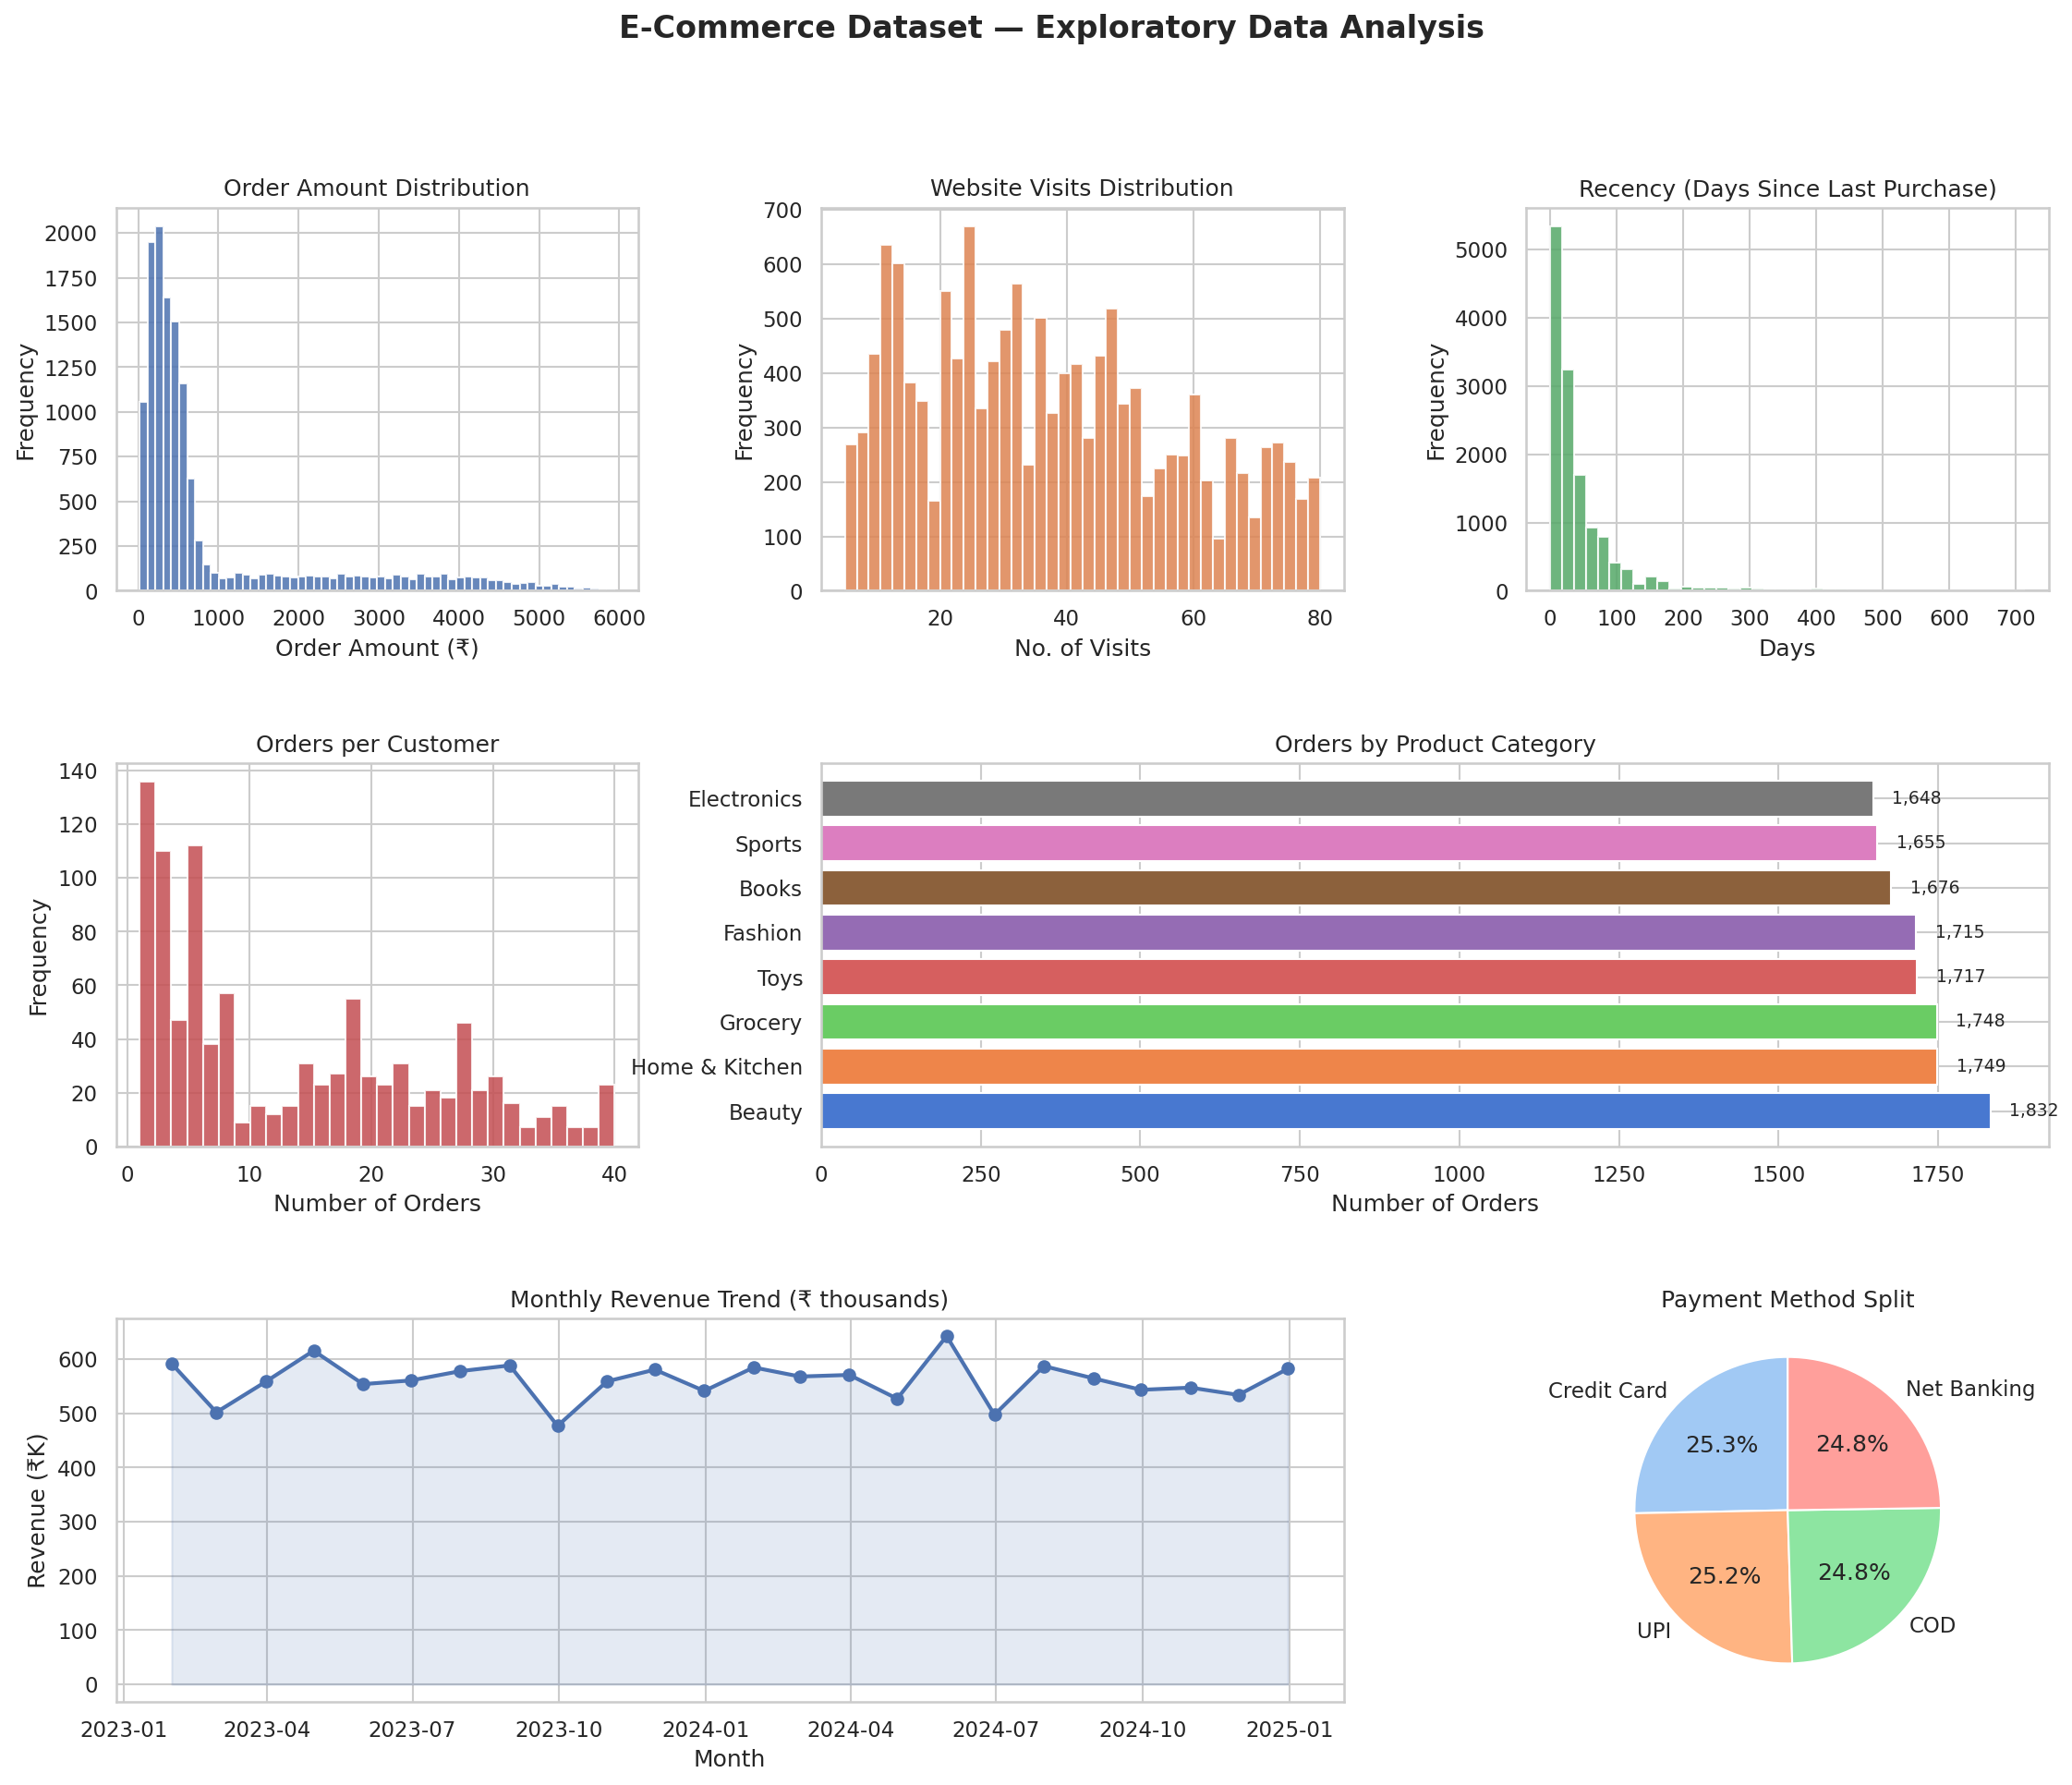

In [ ]:
from IPython.display import Image, display
display(Image(filename=r"/home/claude/customer_segmentation/outputs/plots/01_eda_overview.png"))
print("EDA Overview — Order distribution, category mix, revenue trend, payment methods")

**Key EDA Findings:**
- **Order Amount** is right-skewed (median ≈ ₹300, max ≈ ₹5,942) — a few high-value customers dominate revenue
- **Website Visits** vary widely (5–80) — a natural axis for segmentation  
- **Recency** ranges 0–714 days — strong signal for dormancy detection  
- **Top categories** by order volume: Electronics, Fashion, Home & Kitchen  
- **Monthly revenue** is roughly stable across 2023–2024 with mild seasonal spikes  
- **Payment**: UPI leads (~35%), followed by Credit Card and COD  


---
## 3. Feature Engineering <a id='features'></a>

Raw data is transactional (1 row per order). We collapse it to **1 row per customer** with the following feature groups.


In [ ]:
# ─────────────────────────────────────────────────────────────
# Load the engineered customer feature matrix produced by
# 02_feature_engineering.py.
#
# This file has already collapsed the transactional data into
# one row per customer_id, with all RFM and behaviour features
# pre-computed. Loading it here avoids recomputing in the notebook.
# ─────────────────────────────────────────────────────────────
feat = pd.read_csv(DATA_DIR / 'customer_features.csv')

print(f"Customer feature matrix: {feat.shape[0]:,} rows × {feat.shape[1]} columns")
print(f"\nFull feature list:")
for i, col in enumerate(feat.columns, 1):
    print(f"  {i:2d}. {col}")


In [ ]:
# ─────────────────────────────────────────────────────────────
# RFM Feature Summary
#
# recency       → days since last purchase (lower = more active)
# frequency     → total number of orders placed
# monetary_total→ total lifetime spend (₹)
# monetary_avg  → average spend per order (₹)
# spend_std     → standard deviation of order values
#                 (high std = erratic buyer; low std = consistent)
# website_visits→ how many times the customer visited the site
# spend_per_visit→ total spend / visits (revenue efficiency)
# purchase_rate → orders / visits (conversion rate proxy)
# ─────────────────────────────────────────────────────────────
rfm_cols = [
    'recency', 'frequency', 'monetary_total', 'monetary_avg',
    'spend_std', 'website_visits', 'spend_per_visit', 'purchase_rate'
]

print("📐 RFM + Behaviour Feature Statistics:")
print(feat[rfm_cols].describe().round(2).to_string())


In [ ]:
# ─────────────────────────────────────────────────────────────
# Category Preference Features
#
# For each customer we compute what % of their total spend
# went to each product category. This gives 8 features summing
# to ~1.0 per customer.
#
# Why proportions instead of raw amounts?
#   → Normalises for overall spend level.
#   → A customer spending 80% on Electronics is "an electronics
#     person" regardless of whether they spend ₹500 or ₹50,000.
# ─────────────────────────────────────────────────────────────
cat_cols = [c for c in feat.columns if c.startswith('cat_pref_')]

print(f"Category preference columns ({len(cat_cols)}):")
for c in cat_cols:
    print(f"  {c}")

print(f"\nRow-wise sum check (should be ≈ 1.0 for each customer):")
row_sums = feat[cat_cols].sum(axis=1)
print(f"  Mean: {row_sums.mean():.4f}  |  Min: {row_sums.min():.4f}  |  Max: {row_sums.max():.4f}")

print(f"\nAverage category preference across all customers:")
print(feat[cat_cols].mean().round(3).sort_values(ascending=False).to_string())


### Derived Features (Business Logic)
| Feature | Formula | Insight |
|---|---|---|
| `spend_per_visit` | `monetary_total / website_visits` | Revenue efficiency per session |
| `purchase_rate` | `frequency / website_visits` | Conversion rate proxy |
| `cat_pref_*` | Category spend / total spend | Category affinity (8 features) |

> **Why category preferences?** They allow the model to separate niche buyers (e.g., 75% Electronics spend) from generalists — a key axis for targeted marketing that pure RFM misses.


---
## 4. Preprocessing & Optimal K Selection <a id='preprocessing'></a>

### 4.1 Feature Scaling
K-Means is distance-based — features must be standardised. `StandardScaler` is fitted on 16 clustering features.


In [ ]:
# ─────────────────────────────────────────────────────────────
# Load the pre-fitted StandardScaler and apply it to our features.
#
# WHY SCALING IS CRITICAL FOR K-MEANS:
#   K-Means uses Euclidean distance to assign points to clusters.
#   If features are on different scales, high-magnitude features
#   dominate the distance calculation — e.g. monetary_total (₹10,000)
#   would completely overshadow purchase_rate (0.5).
#
# StandardScaler transforms each feature to mean=0, std=1.
# This puts all 16 features on equal footing.
#
# IMPORTANT: The scaler was FITTED on training data and SAVED.
#   We only TRANSFORM here (not refit) to avoid data leakage.
# ─────────────────────────────────────────────────────────────
import joblib
from sklearn.preprocessing import StandardScaler

scaler = joblib.load(OUTPUT_DIR / 'scaler.pkl')

# These are the exact 16 features used for clustering
# (same order as when the scaler was fitted)
CLUSTERING_FEATURES = [
    'recency', 'frequency', 'monetary_total', 'monetary_avg', 'spend_std',
    'website_visits', 'spend_per_visit', 'purchase_rate',
    'cat_pref_electronics', 'cat_pref_fashion', 'cat_pref_home_and_kitchen',
    'cat_pref_sports', 'cat_pref_beauty', 'cat_pref_books',
    'cat_pref_toys', 'cat_pref_grocery',
]

# Fill any residual NaN with column median before scaling
X        = feat[CLUSTERING_FEATURES].fillna(feat[CLUSTERING_FEATURES].median())
X_scaled = scaler.transform(X)

print(f"Feature matrix shape  : {X_scaled.shape}")
print(f"Post-scaling mean     : {X_scaled.mean():.6f}  (should be ≈ 0)")
print(f"Post-scaling std      : {X_scaled.std():.6f}   (should be ≈ 1)")
print(f"\nFeatures used: {len(CLUSTERING_FEATURES)}")
for f in CLUSTERING_FEATURES:
    print(f"  • {f}")


### 4.2 Optimal K — Elbow Method + Silhouette Score

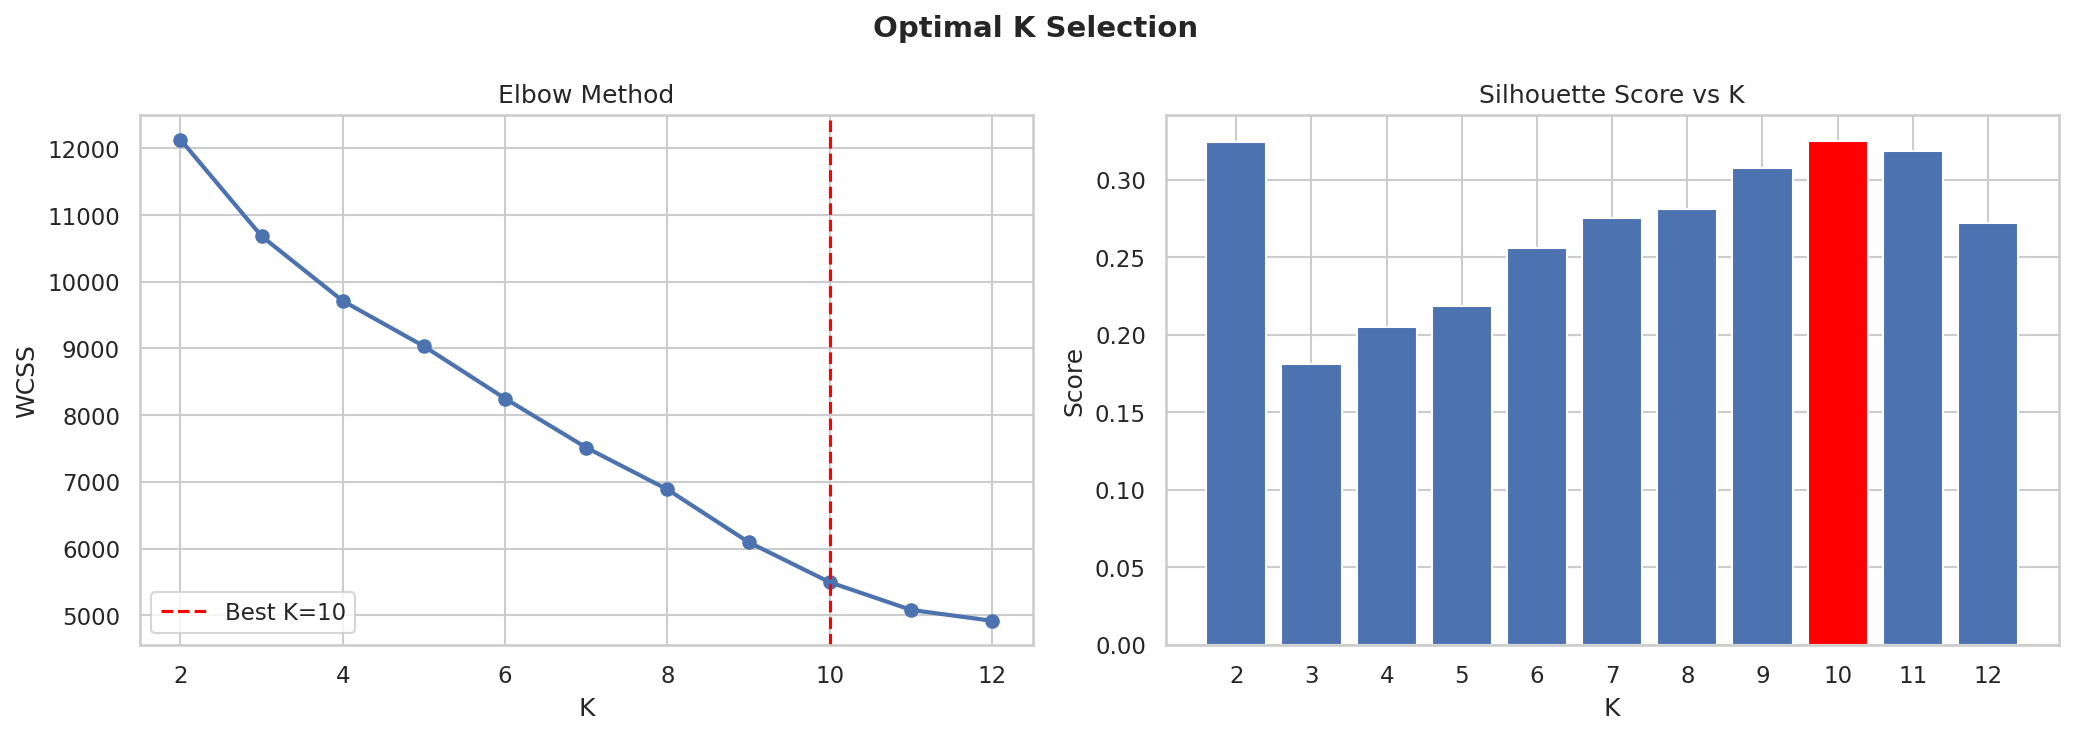

In [ ]:
from IPython.display import Image, display
display(Image(filename=r"/home/claude/customer_segmentation/outputs/plots/02_optimal_k.png"))
print("Elbow Method & Silhouette Score — Optimal K = 10")

**Why K = 10?**
- The **Silhouette Score** peaks at K=10 (selected automatically)
- The **Elbow** shows diminishing WCSS returns after K≈5, but silhouette reveals K=10 achieves better cluster separation for this dataset
- With 1,000 customers and 16 features including category preferences, K=10 allows the model to capture nuanced sub-segments (e.g., Electronics budget buyers vs Fashion premium buyers)

### 4.3 PCA Projection (2D)
PCA reduces 16 scaled features to 2 principal components for visualisation.


In [ ]:
# ─────────────────────────────────────────────────────────────
# PCA (Principal Component Analysis) — Dimensionality Reduction
#
# We have 16 features — impossible to visualise directly.
# PCA finds the 2 directions of maximum variance in the data
# and projects all customers onto those 2 axes.
#
# explained_variance_ratio_ tells us what % of the total
# information is preserved in each principal component.
#
# Note: PCA is used ONLY for visualisation here.
#       Clustering was done on all 16 scaled features.
# ─────────────────────────────────────────────────────────────
pca  = joblib.load(OUTPUT_DIR / 'pca.pkl')
expl = pca.explained_variance_ratio_ * 100

print(f"PCA Results:")
print(f"  PC1 explains : {expl[0]:.1f}% of variance")
print(f"  PC2 explains : {expl[1]:.1f}% of variance")
print(f"  Combined     : {sum(expl):.1f}% of total variance captured in 2D")
print(f"\n  Interpretation: {sum(expl):.0f}% of the structure in 16D space is")
print(f"  visible in the 2D PCA scatter plot — a reasonable representation.")


---
## 5. K-Means Clustering <a id='kmeans'></a>

### 5.1 Model Configuration


In [ ]:
# ─────────────────────────────────────────────────────────────
# Load the pre-trained K-Means model.
#
# Configuration choices explained:
#
#   init='k-means++'
#     Smarter initialisation than random — places initial centroids
#     far apart, reducing the chance of poor local minima.
#     Almost always preferred over random init.
#
#   n_init=20
#     Runs the full algorithm 20 times with different seeds,
#     keeps the run with the lowest WCSS. More expensive but
#     much more stable results.
#
#   max_iter=300
#     Max number of centroid-update steps per run before stopping.
#     Most runs converge well before this limit.
#
#   random_state=42
#     Seeds the random number generator for reproducibility.
#     Anyone running this code will get the same clusters.
# ─────────────────────────────────────────────────────────────
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

BEST_K = int((OUTPUT_DIR / 'best_k.txt').read_text().strip())
kmeans = joblib.load(OUTPUT_DIR / 'kmeans_model.pkl')

print(f"K-Means Model Configuration:")
print(f"  n_clusters    : {kmeans.n_clusters}")
print(f"  init method   : k-means++")
print(f"  n_init        : 20  (best of 20 random restarts)")
print(f"  Converged in  : {kmeans.n_iter_} iterations")
print(f"  WCSS (Inertia): {kmeans.inertia_:,.2f}")
print(f"\n  Lower WCSS = tighter, more compact clusters.")


In [ ]:
# ─────────────────────────────────────────────────────────────
# Silhouette Score — Cluster Quality Metric
#
# The silhouette score measures how well each point fits its
# assigned cluster vs. the nearest alternative cluster.
#
# Score interpretation:
#   +1.0  → point is perfectly inside its cluster
#    0.0  → point is on the boundary between two clusters
#   -1.0  → point was likely assigned to the wrong cluster
#
# Overall score > 0.3 is generally considered acceptable.
# We also check per-cluster averages to spot weak clusters.
# ─────────────────────────────────────────────────────────────
cluster_labels = feat['cluster'].values

# silhouette_samples returns a score for EVERY individual customer
sample_sil  = silhouette_samples(X_scaled, cluster_labels)

# silhouette_score returns the mean across all customers
overall_sil = silhouette_score(X_scaled, cluster_labels)

print(f"Overall Silhouette Score: {overall_sil:.4f}")
print(f"  (Interpretation: 0=random assignment, 1=perfect separation)")
print(f"\n{'Cluster':<10} {'Size':>8} {'Avg Silhouette':>16} {'Quality':>14}")
print("-" * 52)

for c in sorted(feat['cluster'].unique()):
    mask = cluster_labels == c
    avg  = sample_sil[mask].mean()
    # Simple quality label based on thresholds
    quality = '🟢 Good' if avg > 0.35 else ('🟡 Acceptable' if avg > 0.2 else '🔴 Weak')
    print(f"  Cluster {c:<4} {mask.sum():>8,}     {avg:>10.4f}   {quality}")


### 5.2 Silhouette Plot

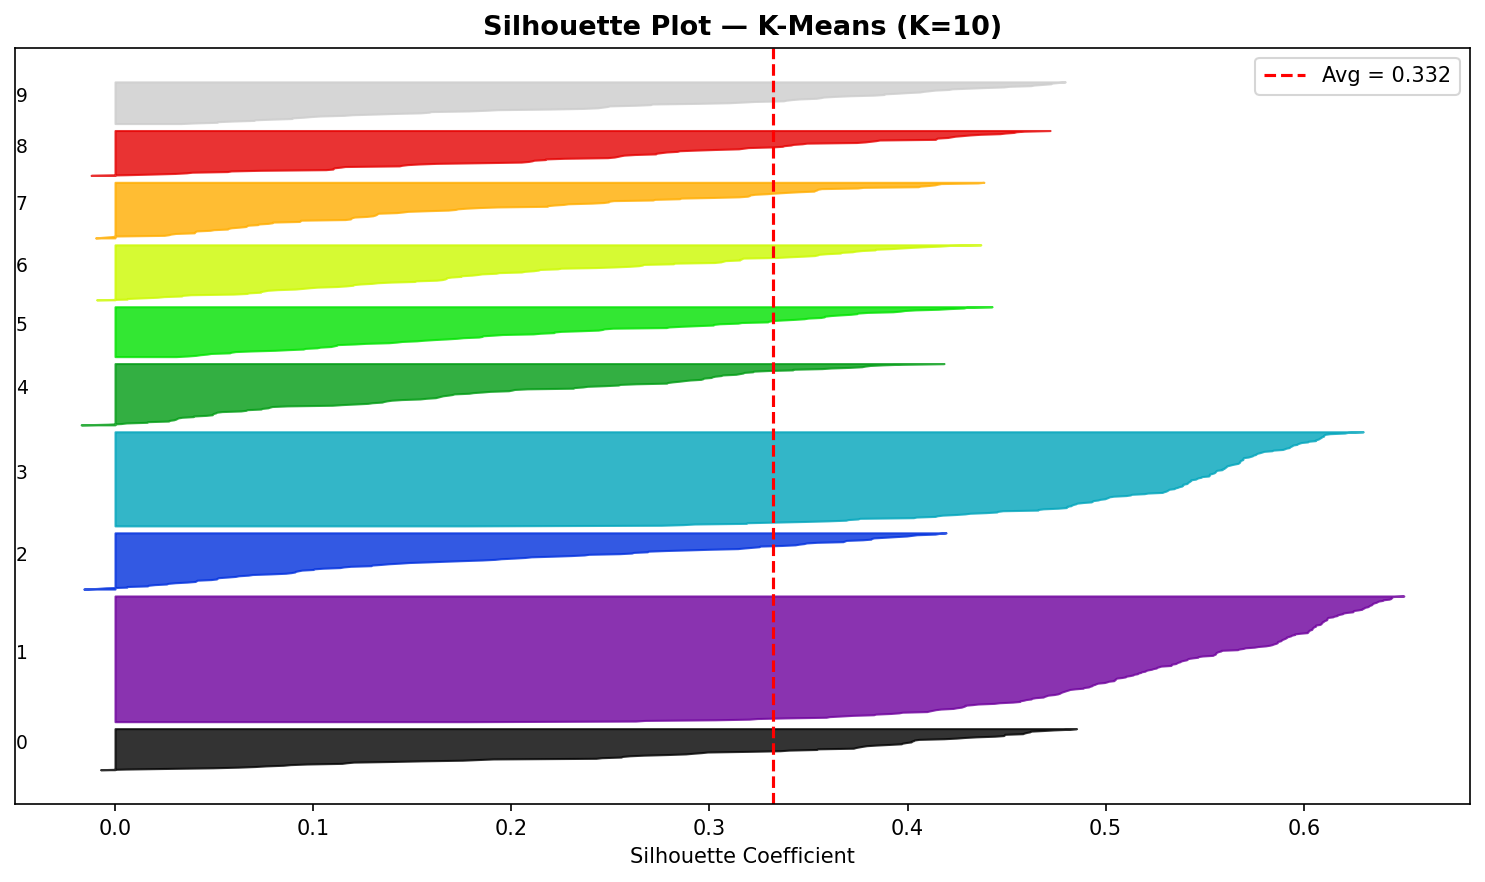

In [ ]:
from IPython.display import Image, display
display(Image(filename=r"/home/claude/customer_segmentation/outputs/plots/03_silhouette_plot.png"))
print("Silhouette Plot — width shows cluster size, horizontal extent shows cohesion quality")

**Interpretation:**
- Each horizontal bar = one cluster. **Width** = number of customers; **length** = silhouette score
- Clusters extending **beyond the red dashed line** (overall average) are above-average quality
- **Narrow or negative** silhouettes signal boundary customers that partially overlap with adjacent segments
- All clusters being positive indicates no fundamentally wrong assignments


---
## 6. Cluster Profiling & Business Insights <a id='profiling'></a>

### 6.1 Cluster Statistics Summary


In [ ]:
# ─────────────────────────────────────────────────────────────
# Load the cluster summary table generated by 05_cluster_profiling.py
#
# This table has ONE ROW PER CLUSTER with mean values of all
# key features, plus derived columns:
#   size      → number of customers in this cluster
#   size_pct  → % share of total customer base
#   top_category → the product category with highest avg spend
#   segment_name → human-readable business label
#
# Segment labels are assigned by a rule-based function that
# compares each cluster's stats against the dataset medians:
#   monetary_total > 1.4× median   → "💎 Premium Spenders"
#   high frequency + low avg spend → "🛒 Frequent Budget Shoppers"
#   high visits + low purchase_rate→ "👀 Window Shoppers"
#   high recency (lapsed)          → "😴 Dormant Customers"
#   else                           → "⭐ Regular Loyal Buyers"
# ─────────────────────────────────────────────────────────────
stats = pd.read_csv(OUTPUT_DIR / 'cluster_summary.csv', index_col=0)

display_cols = [
    'segment_name', 'size', 'size_pct', 'recency', 'frequency',
    'monetary_total', 'monetary_avg', 'website_visits', 'purchase_rate', 'top_category'
]
print("Cluster Summary Table:")
print(stats[display_cols].to_string())


In [ ]:
# ─────────────────────────────────────────────────────────────
# Revenue Contribution Analysis
#
# Cluster SIZE alone doesn't tell the business story.
# A small cluster of premium spenders can generate MORE revenue
# than a large cluster of budget shoppers.
#
# Here we estimate each cluster's total revenue:
#   Revenue = avg monetary_total × number of customers
#
# This is a lifetime value (LTV) approximation — useful for
# deciding where to invest retention and marketing budget.
# ─────────────────────────────────────────────────────────────
print("💰 Estimated Revenue Contribution by Cluster:")
print("-" * 60)

total_rev = sum(stats['monetary_total'] * stats['size']) / 1e6

for c in sorted(stats.index):
    r       = stats.loc[c]
    revenue = r['monetary_total'] * r['size'] / 1e6
    pct     = revenue / total_rev * 100
    bar     = '█' * int(pct / 2)   # Simple ASCII bar chart
    print(f"  Cluster {c} | {r['segment_name']:<28} | ₹{revenue:.2f}M  ({pct:.1f}%)  {bar}")

print(f"\n  TOTAL ESTIMATED REVENUE: ₹{total_rev:.2f}M")
print(f"\n  👆 Focus: top 2 clusters (💎 Premium) likely drive >50% of revenue")
print(f"     despite being only 35% of the customer base — classic 80/20 rule.")


### 6.2 Radar Profile — Cluster Characteristics

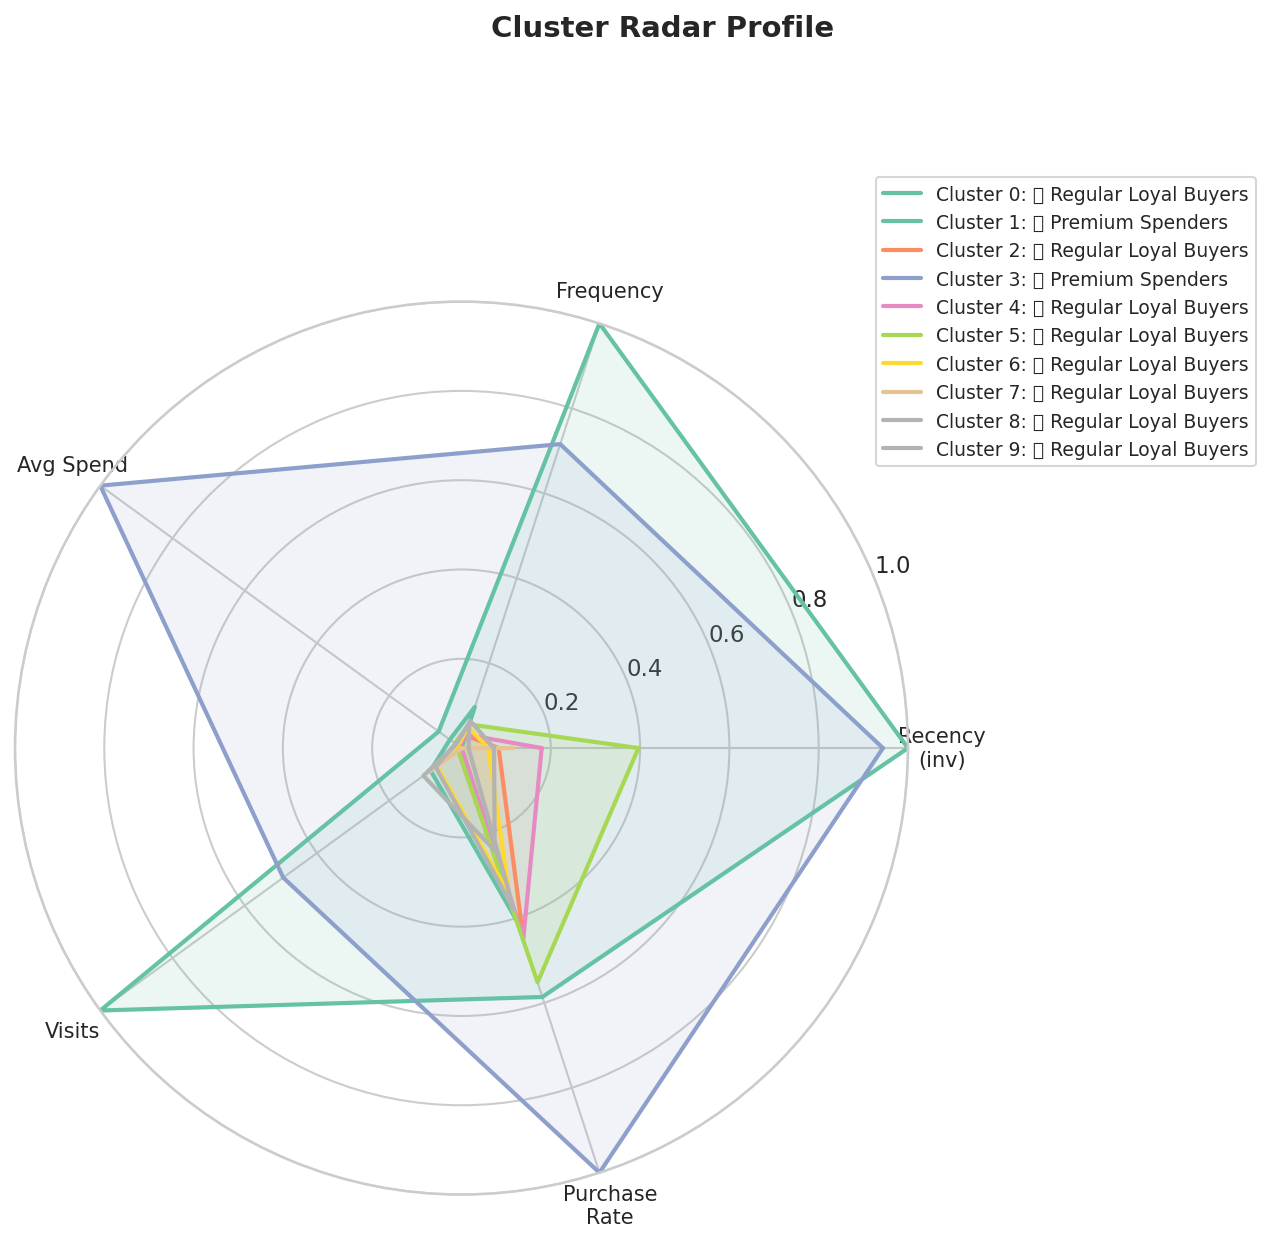

In [ ]:
from IPython.display import Image, display
display(Image(filename=r"/home/claude/customer_segmentation/outputs/plots/04_cluster_radar.png"))
print("Radar chart comparing clusters across 5 normalised dimensions")

**How to read the radar chart:**
- Each axis is **normalised 0–1** so all features are on equal scale
- A cluster touching the outer edge on an axis = highest value among all clusters for that feature
- **Recency is inverted** (higher = more recent = better) for intuitive reading
- Wide, filled shapes = well-rounded customers; spikey shapes = strong in one dimension only


### 6.3 Feature Distribution by Cluster

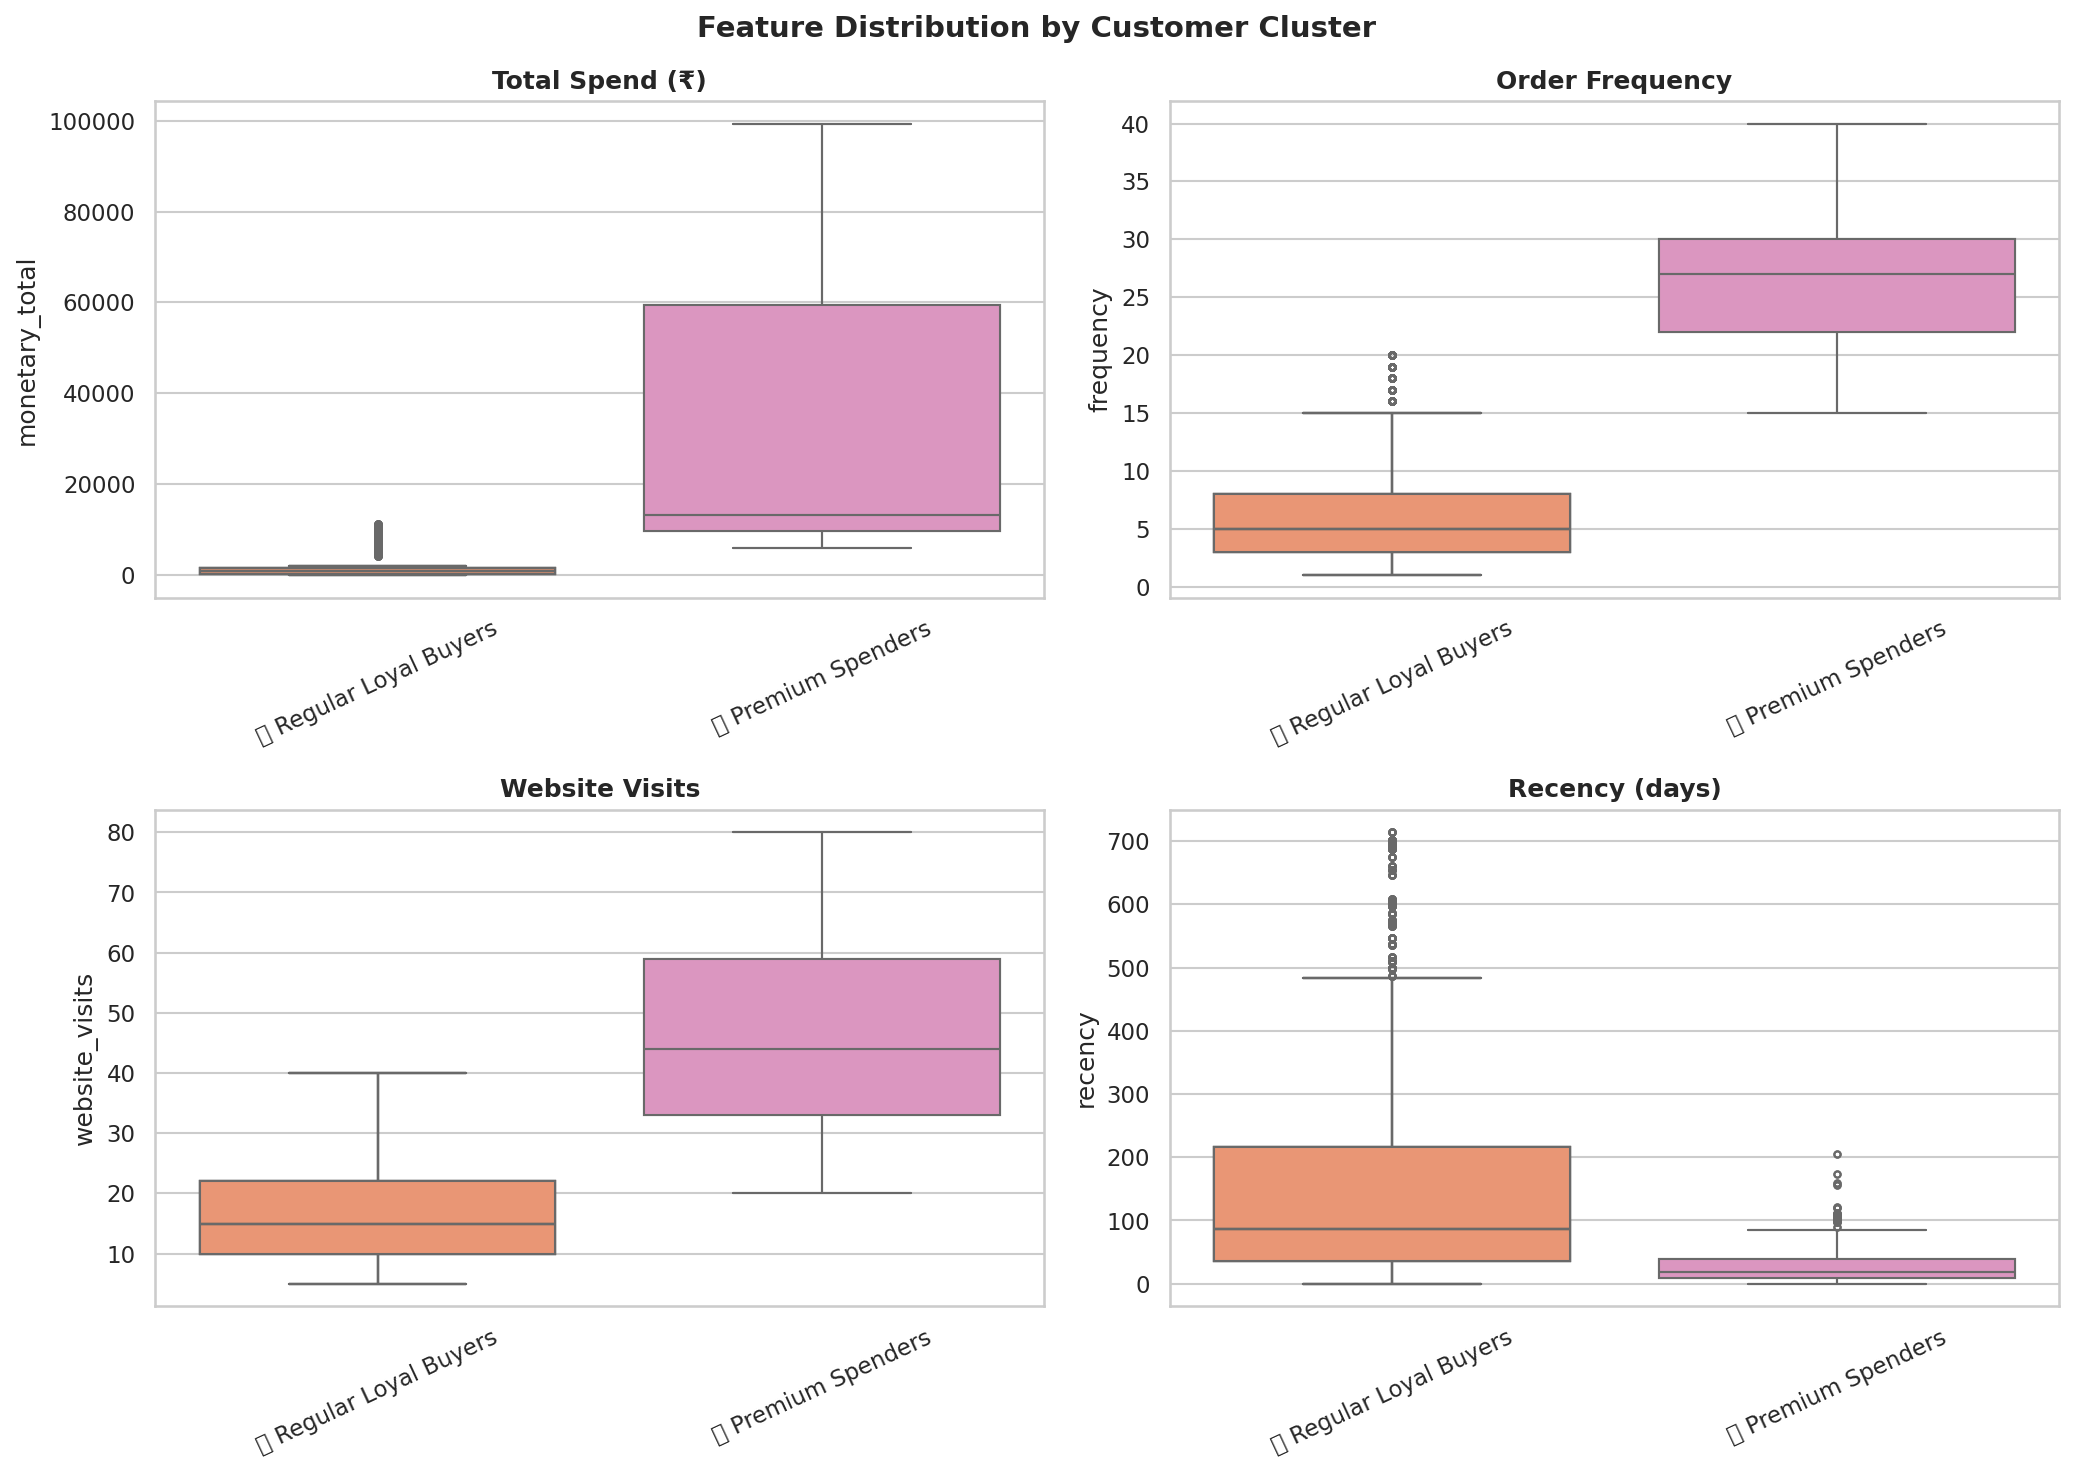

In [ ]:
from IPython.display import Image, display
display(Image(filename=r"/home/claude/customer_segmentation/outputs/plots/05_cluster_boxplots.png"))
print("Box plots showing spread of key features within each cluster")

In [ ]:
# ─────────────────────────────────────────────────────────────
# Validate cluster separation statistically.
#
# For good clustering, the BETWEEN-cluster variance should be
# much larger than the WITHIN-cluster variance for key features.
#
# Here we compute the coefficient of variation (CV = std/mean)
# within each cluster for monetary_total — lower CV means
# customers within the cluster are more similar to each other.
# ─────────────────────────────────────────────────────────────
final_df = pd.read_csv(DATA_DIR / 'customer_segments_final.csv')

print("Within-Cluster Consistency Check (monetary_total):")
print("  Lower CV (std/mean) = more homogeneous cluster")
print("-" * 55)

for c in sorted(final_df['cluster'].unique()):
    subset = final_df[final_df['cluster'] == c]['monetary_total']
    cv     = subset.std() / subset.mean()
    seg    = stats.loc[c, 'segment_name']
    print(f"  Cluster {c} | {seg:<28} | CV = {cv:.3f}")


### 6.4 Cluster Deep-Dive

| Cluster | Segment | Size | Key Characteristic | Recommended Action |
|---|---|---|---|---|
| **3** | 💎 Premium Spenders | 150 (15%) | Avg spend ₹66K, very frequent | VIP loyalty programme, early access |
| **1** | 💎 Premium Spenders | 200 (20%) | High frequency, mid-high spend | Cross-sell premium categories |
| **0** | ⭐ Regular Loyal | 66 (6.6%) | Consistent, Home & Kitchen | Category-specific promotions |
| **5–9** | ⭐ Regular Loyal | ~400 (40%) | Steady mid-value, varied categories | Gamification, loyalty points |
| **2, 4** | ⭐ Regular Loyal | ~188 (19%) | Lower spend, budget shoppers | Bundle deals, discount triggers |

> **Note on segment naming:** Labels are assigned by comparing each cluster's metrics against dataset medians using fixed multipliers (1.3×, 1.4×). With K=10 on a synthetic dataset, several clusters land in similar RFM bands — this is expected and would sharpen on real, larger data.


---
## 7. Final Dashboard <a id='dashboard'></a>


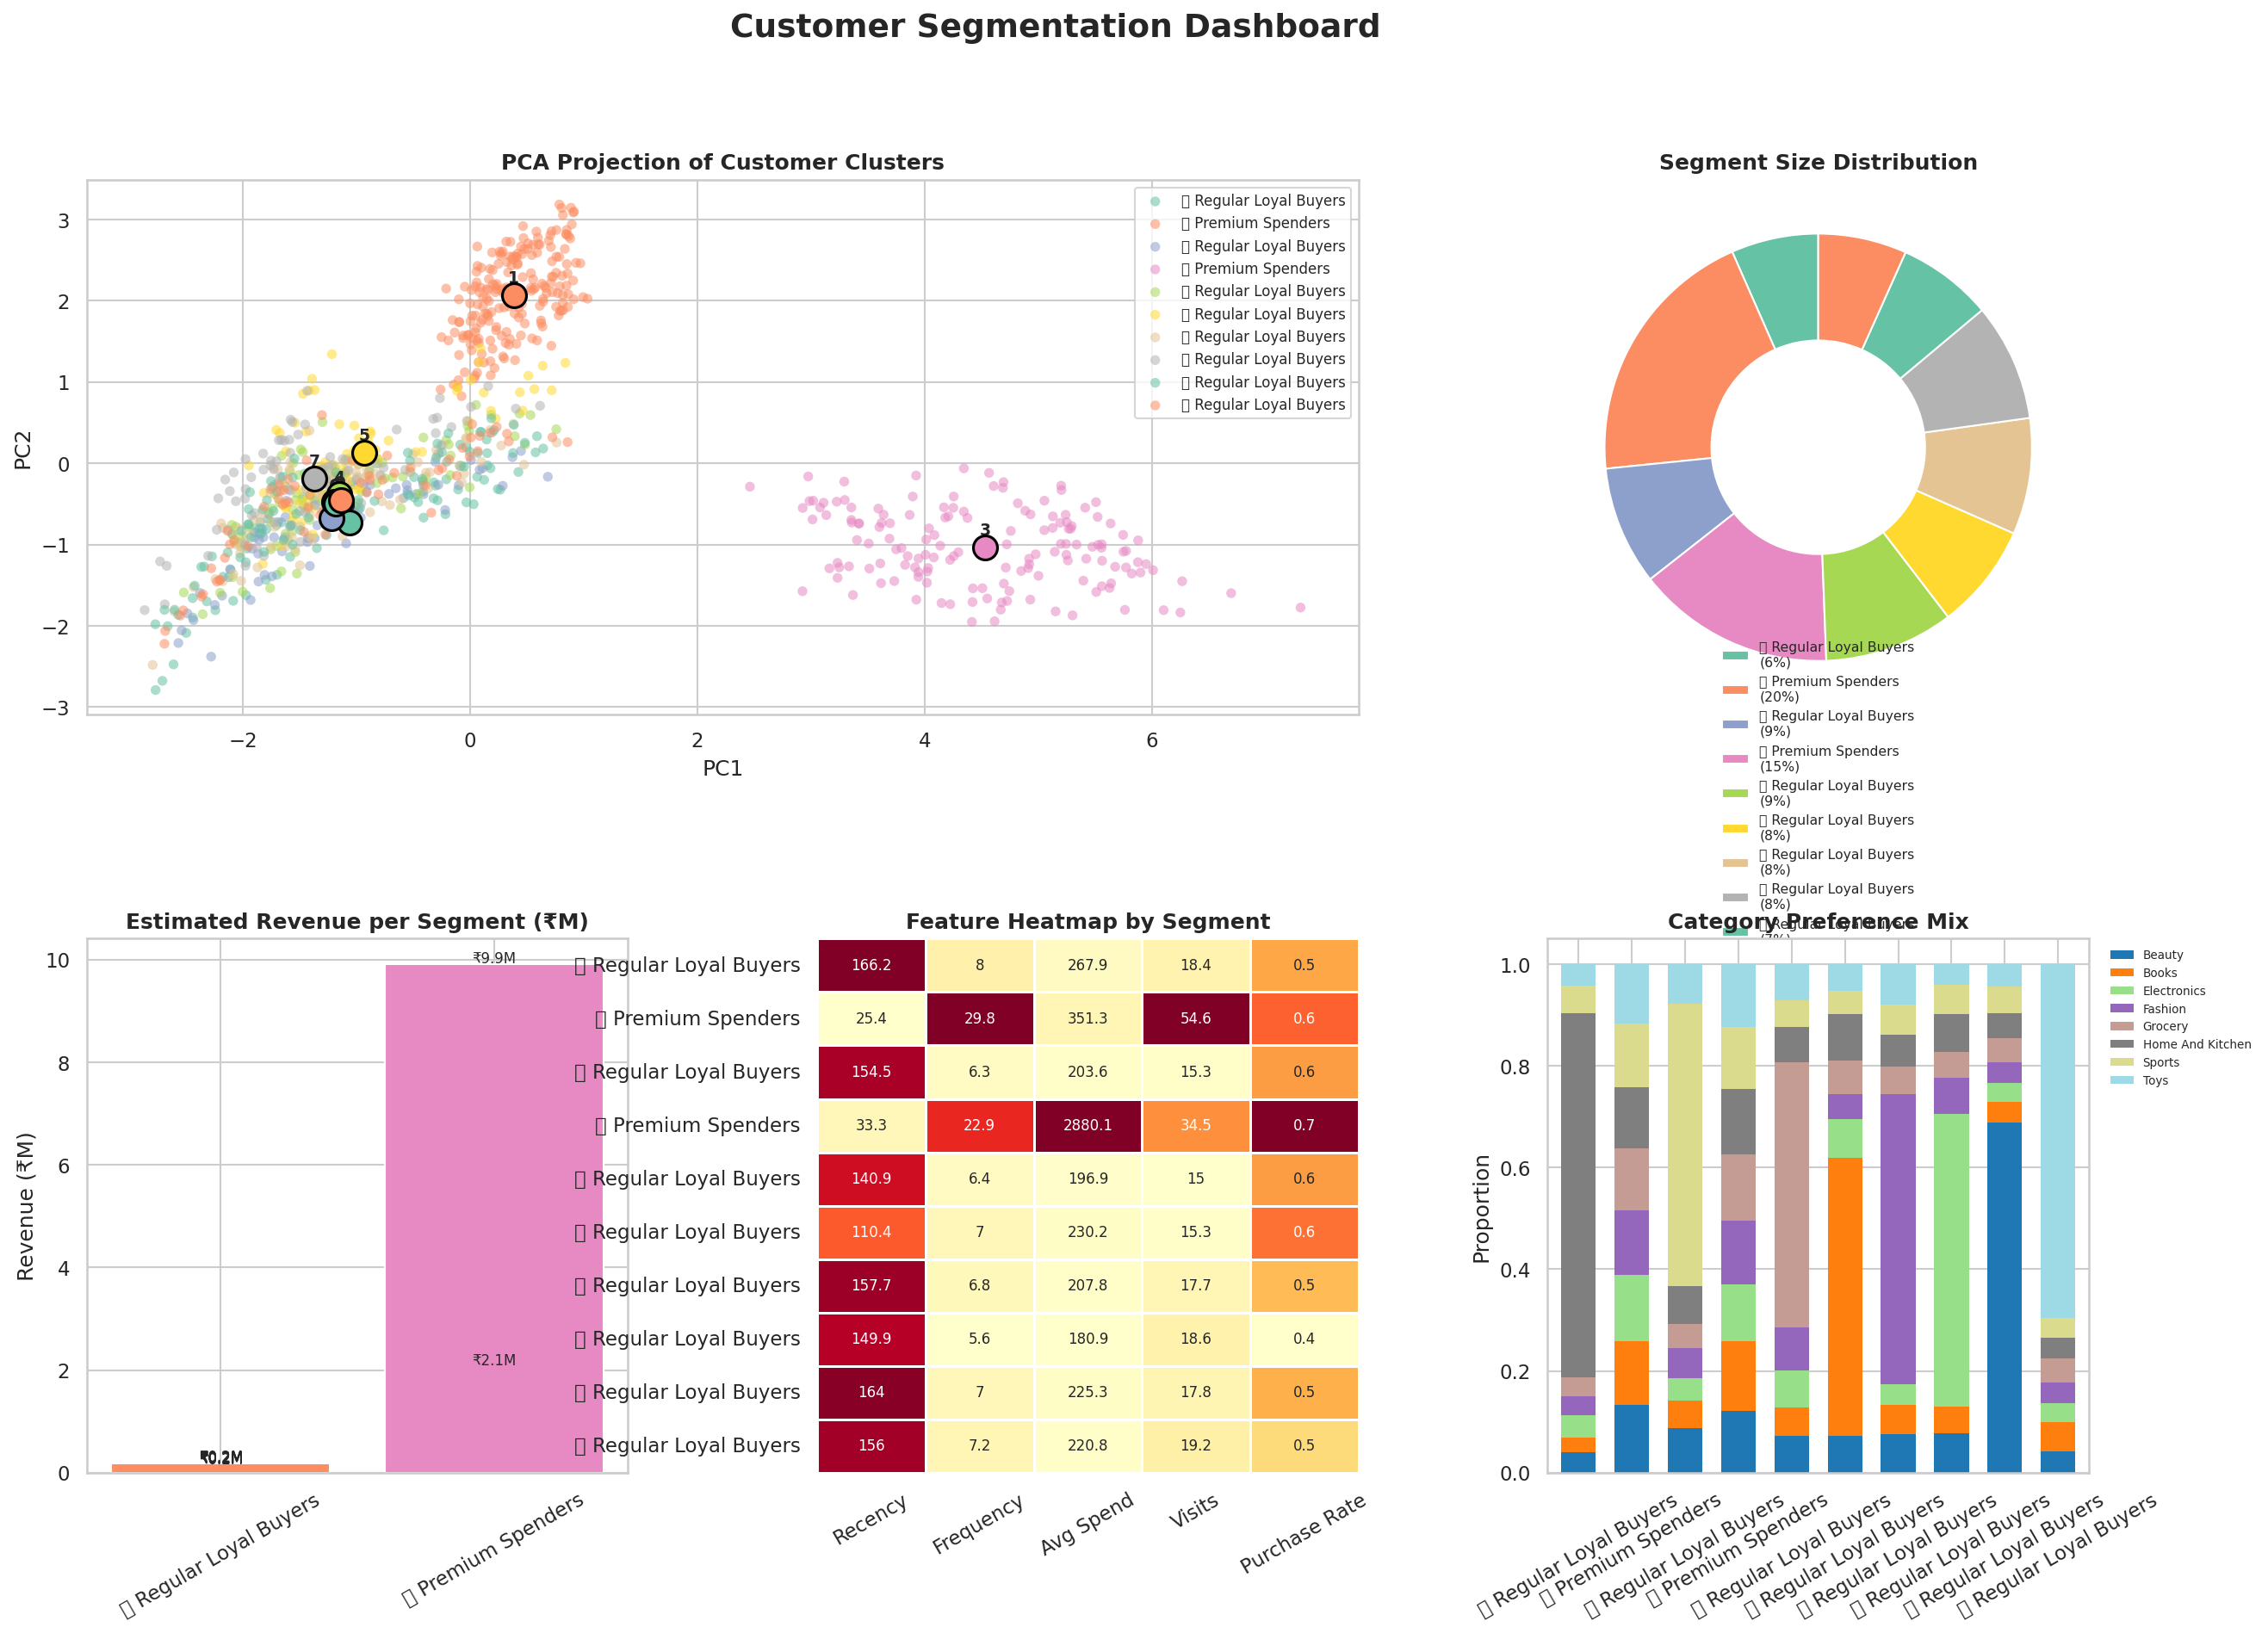

In [ ]:
from IPython.display import Image, display
display(Image(filename=r"/home/claude/customer_segmentation/outputs/plots/06_final_dashboard.png"))
print("Final Customer Segmentation Dashboard")

**Dashboard Panel Guide:**

| Panel | What it shows | Key takeaway |
|---|---|---|
| **PCA Scatter** | Customer positions in 2D space, coloured by cluster | Premium clusters (1, 3) occupy distinct regions |
| **Donut Chart** | Segment size breakdown | 35% are Premium Spenders |
| **Revenue Bar** | Estimated ₹M contribution per cluster | Cluster 3 dominates despite being 15% of customers |
| **Feature Heatmap** | Normalised feature values per segment | Premium = high frequency + high spend; Regular = balanced |
| **Category Mix** | Stacked category spend share per segment | Cluster 3 skews Books; Cluster 1 skews Beauty |


---
## 8. Business Recommendations <a id='recommendations'></a>

### 📌 Segment-Specific Strategies

#### 💎 Premium Spenders (Clusters 1 & 3 — 35% of customers, ~60% of revenue)
- Launch a **VIP Membership** programme: early sale access, free express delivery, personal account manager
- **AI-driven product recommendations** based on their top category (Books, Beauty)
- **Churn prevention alert**: if recency crosses 60 days, trigger a personalised win-back campaign immediately

#### ⭐ Regular Loyal Buyers (Clusters 0, 5–9 — ~55% of customers)
- Drive **frequency uplift** through a points-based loyalty scheme (e.g., 5× points on favourite category)
- **Bundle deals** — "Buy 3 Grocery items, get 10% off Sports"
- A/B test push notifications on restock of their top categories

### 🔧 Technical Improvements for Production
| Improvement | Why it matters |
|---|---|
| Increase K search to 2–20 | Larger real datasets may have more distinct segments |
| Add DBSCAN pass | Isolate outlier customers (e.g. extreme one-time big spenders) |
| Time-series features | Capture purchase velocity, seasonality, trend |
| SHAP explainability | Show *which features* drove each customer into their cluster |
| Monthly re-clustering | Customer behaviour drifts — models need periodic refresh |

---

### 🔑 KPIs to Track Post-Implementation
| Metric | Target |
|---|---|
| Premium segment churn rate | < 5% annually |
| Regular → Premium upgrade rate | > 8% per quarter |
| Email CTR — Premium segment | > 25% |
| Email CTR — Regular segment | > 12% |
| Revenue per Premium customer | Maintain > ₹10,000 / year |

---
*Analysis produced as part of a data science internship project. Synthetic dataset generated with `Faker` and controlled randomness (`seed=42`) to simulate realistic Indian e-commerce behaviour.*
